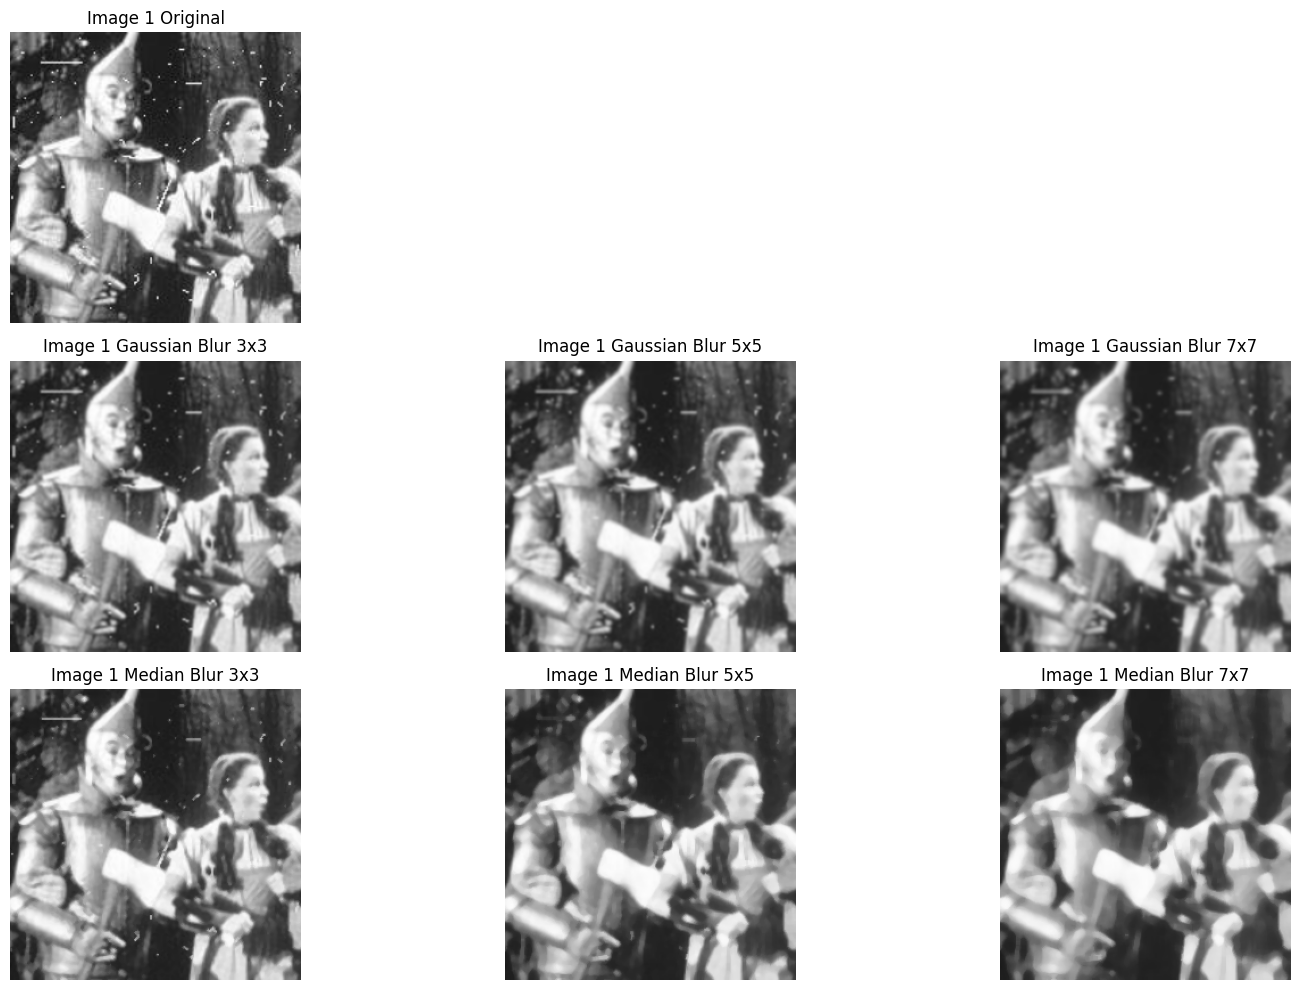

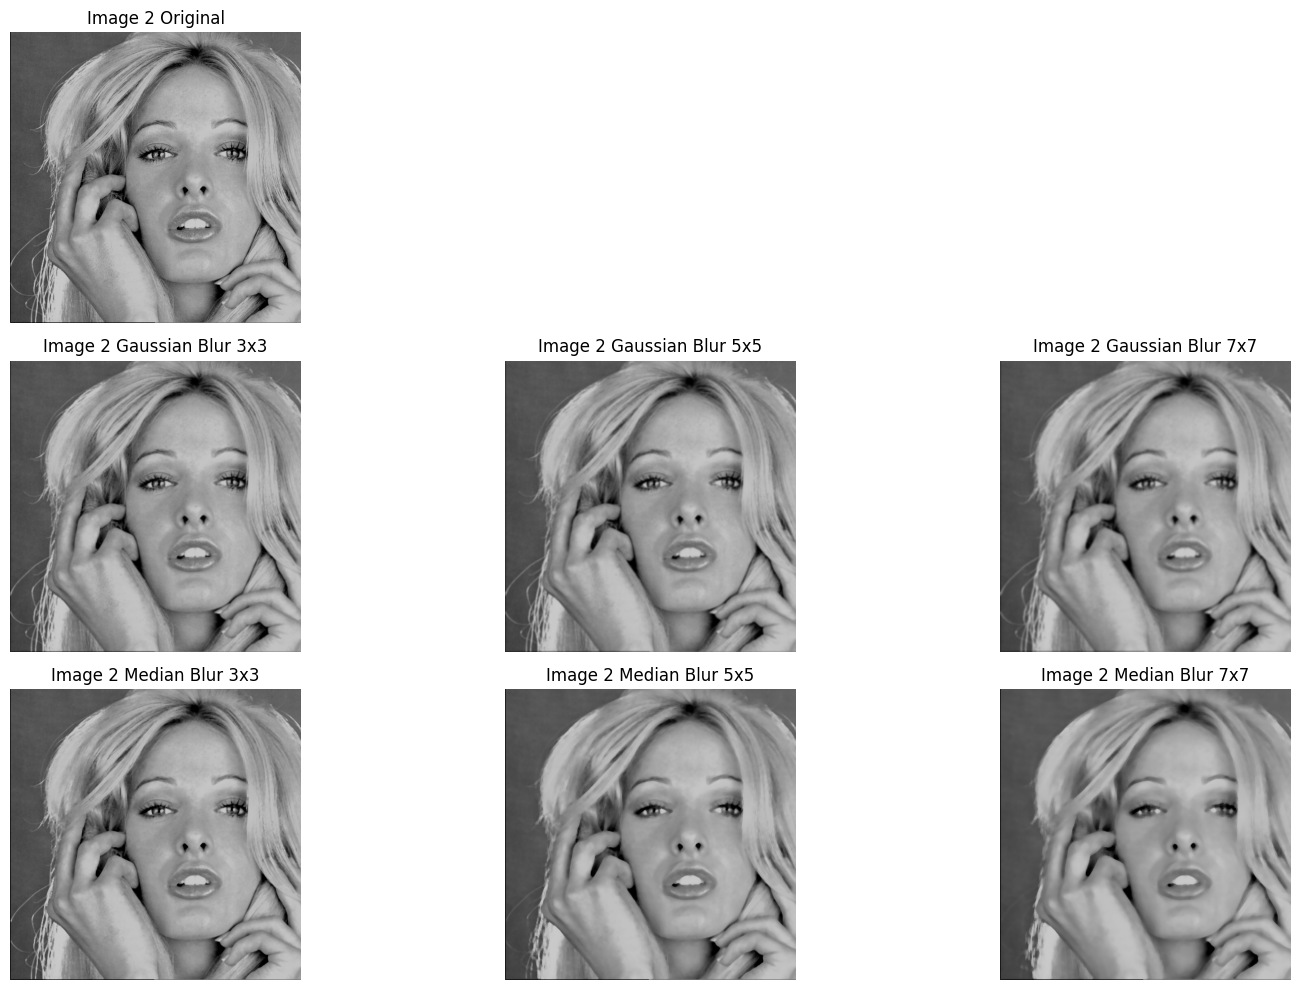

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread('test1.pgm')
img2 = cv2.imread('test2.tif')

def process_and_show(img, title):
    sizes = [3, 5, 7]
    plt.figure(figsize=(15, 10))

    plt.subplot(3, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title(f'{title} Original')
    plt.axis('off')
    for i, size in enumerate(sizes):
        gaussian = cv2.GaussianBlur(img, (size, size), 0)
        median = cv2.medianBlur(img, size)
        plt.subplot(3, 3, i + 4)
        plt.imshow(gaussian, cmap='gray')
        plt.title(f'{title} Gaussian Blur {size}x{size}')
        plt.axis('off')

        plt.subplot(3, 3, i + 7)
        plt.imshow(median, cmap='gray')
        plt.title(f'{title} Median Blur {size}x{size}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

if img1 is not None:
    process_and_show(img1, 'Image 1')

if img2 is not None:
    process_and_show(img2, 'Image 2')

In [2]:
import numpy as np

def generate_gaussian_kernel(sigma, size):
    """
    根据讲义公式产生高斯滤波器
    :param sigma: 标准差 (例如 1.5)
    :param size: 矩阵尺寸 (例如 7)
    :return: 归一化后的二维浮点数矩阵
    """
    # 1. 建立坐标系，中心点为 (0,0)
    # 对于 size=7, k 的范围是 [-3, -2, -1, 0, 1, 2, 3]
    k = np.arange(size) - (size - 1) // 2
    x, y = np.meshgrid(k, k)
    
    # 2. 按照讲义公式 (7) 计算未归一化的权重
    # p(x,y) = (1 / (2*pi*sigma^2)) * exp(-(x^2 + y^2) / (2*sigma^2))
    # 注意：前面的系数 (1 / 2*pi*sigma^2) 在归一化步骤中会被抵消，所以可以简化
    exponent = -(x**2 + y**2) / (2 * sigma**2)
    kernel = np.exp(exponent)
    
    # 3. 归一化：确保所有元素之和为 1
    # 这样可以保证滤波后的图像亮度不变
    kernel = kernel / np.sum(kernel)
    
    return kernel

# 参数设定
sigma_val = 1.5
kernel_size = 7

# 生成并打印结果
gaussian_mask = generate_gaussian_kernel(sigma_val, kernel_size)

print(f"生成的 {kernel_size}x{kernel_size} 高斯滤波器 (sigma={sigma_val}):")
np.set_printoptions(precision=6, suppress=True) # 优化打印格式
print(gaussian_mask)

# 验证总和是否为 1
print(f"\n矩阵元素总和: {np.sum(gaussian_mask)}")

生成的 7x7 高斯滤波器 (sigma=1.5):
[[0.001342 0.004077 0.00794  0.009916 0.00794  0.004077 0.001342]
 [0.004077 0.012383 0.02412  0.030122 0.02412  0.012383 0.004077]
 [0.00794  0.02412  0.046979 0.058669 0.046979 0.02412  0.00794 ]
 [0.009916 0.030122 0.058669 0.073269 0.058669 0.030122 0.009916]
 [0.00794  0.02412  0.046979 0.058669 0.046979 0.02412  0.00794 ]
 [0.004077 0.012383 0.02412  0.030122 0.02412  0.012383 0.004077]
 [0.001342 0.004077 0.00794  0.009916 0.00794  0.004077 0.001342]]

矩阵元素总和: 1.0


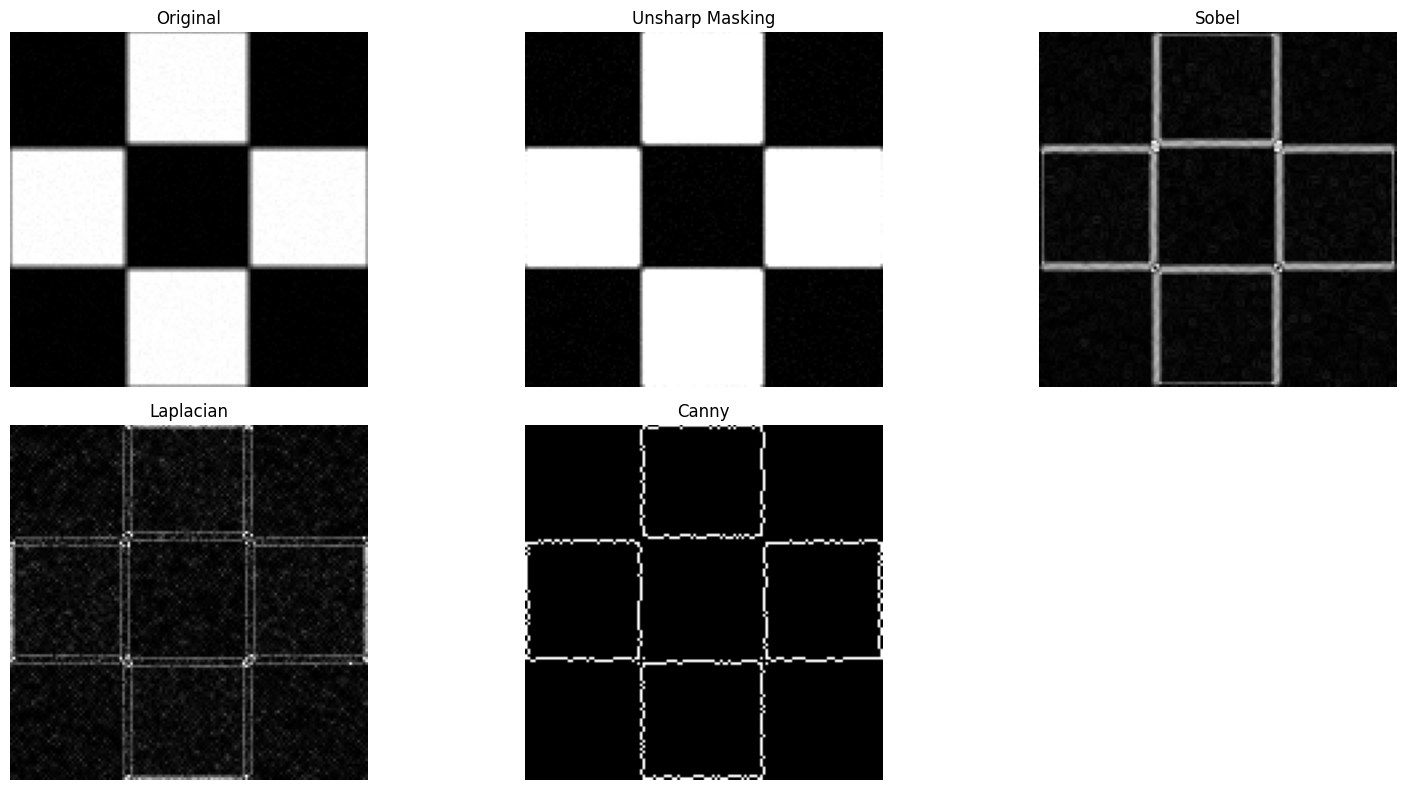

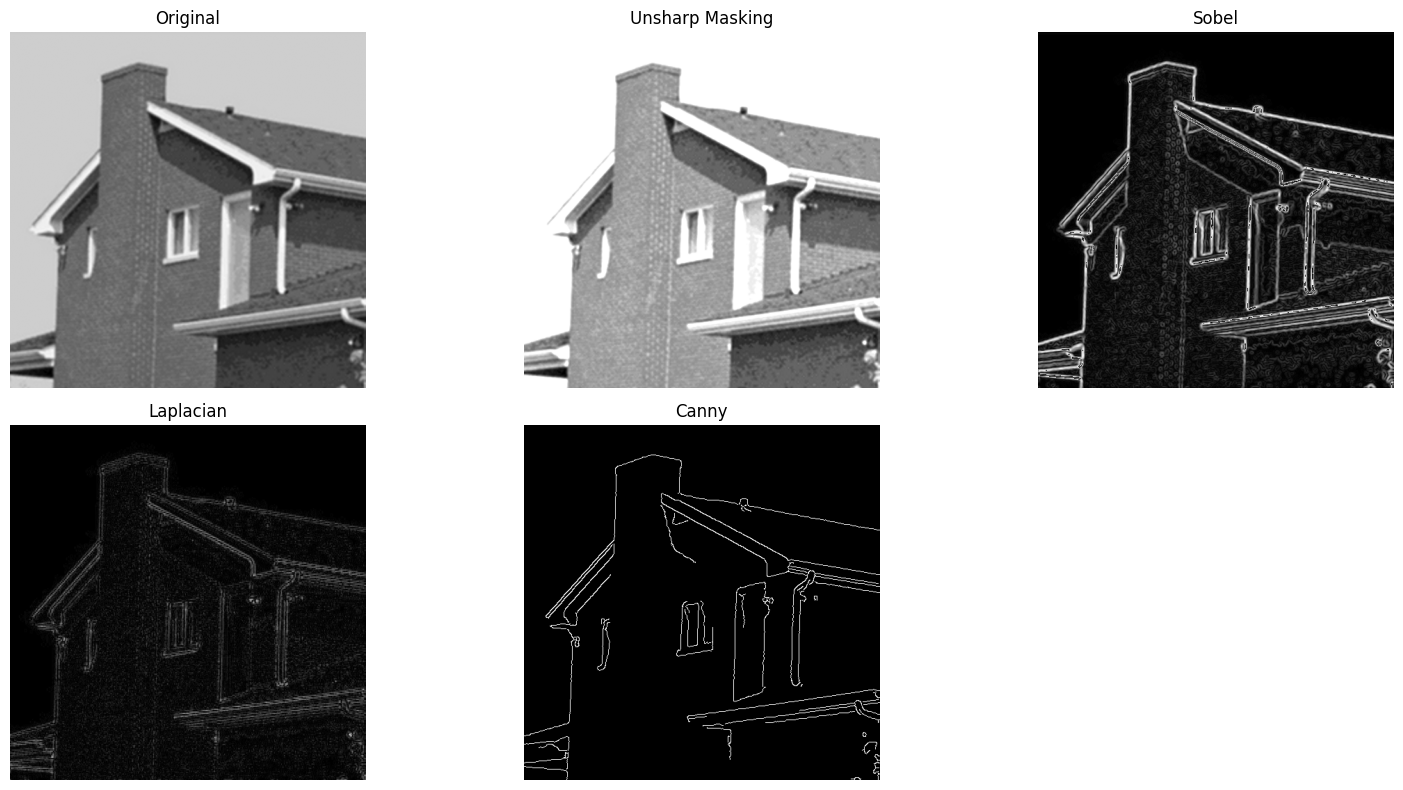

In [3]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

def process_high_pass(image_path):
    # 1. 以灰度模式读取图像
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"无法读取图像: {image_path}")
        return

    # --- 算法 1: Unsharp Masking (反锐化掩模) ---
    # 原理：原图 - 低通(高斯模糊) = 高通分量；原图 + k * 高通 = 锐化
    gaussian_blur = cv2.GaussianBlur(img, (5, 5), 1.5)
    high_pass_mask = cv2.subtract(img, gaussian_blur)
    unsharp_img = cv2.addWeighted(img, 1.5, high_pass_mask, 0.5, 0)

    # --- 算法 2: Sobel Edge Detector (一阶微分) ---
    # 计算水平和垂直梯度并合并
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel_combined = cv2.magnitude(sobelx, sobely)
    sobel_8u = np.uint8(np.absolute(sobel_combined))

    # --- 算法 3: Laplace Edge Detection (二阶微分) ---
    # 直接计算二阶导数，对噪声极其敏感
    laplacian = cv2.Laplacian(img, cv2.CV_64F, ksize=3)
    laplace_8u = np.uint8(np.absolute(laplacian))

    # --- 算法 4: Canny Algorithm (多级优化) ---
    # 包含：高斯去噪 -> 梯度计算 -> 非极大值抑制 -> 双阈值检测
    canny_edges = cv2.Canny(img, 100, 200)

    # --- 结果可视化 ---
    titles = ['Original', 'Unsharp Masking', 'Sobel', 'Laplacian', 'Canny']
    images = [img, unsharp_img, sobel_8u, laplace_8u, canny_edges]

    plt.figure(figsize=(16, 8))
    for i in range(5):
        plt.subplot(2, 3, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# 调用函数测试 test3 和 test4
process_high_pass('test3_corrupt.pgm')
process_high_pass('test4.tif')